In [27]:
import openslide
import cv2 as cv
import os
import io
import numpy as np
import tensorflow as tf
import csv

from tensorflow.keras.models import load_model
from tqdm import tqdm
from skimage.filters import threshold_otsu
from matplotlib import pyplot as plt
from matplotlib import cm
from matplotlib.gridspec import GridSpec
from PIL import Image

from multiprocessing import Pool, Manager
from itertools import product
import time
import threading
from concurrent.futures import ThreadPoolExecutor
from openslide.deepzoom import DeepZoomGenerator
from openslide import OpenSlide


In [15]:
# Carrega a imagem com o OpenSlide
tcga_name = '/home/ampliar/Desktop/aws-ia-heatmap-master/TCGA-BR-7197-01A-01-BS1.2fbf309e-bb43-49d2-aae9-b3016a520722.svs'
wsi = openslide.OpenSlide(tcga_name)
TRASH_HOLD = 0.9

### Imagem em pirâmede

In [16]:
wsi.level_dimensions

((103768, 81322), (25942, 20330), (6485, 5082), (3242, 2541))

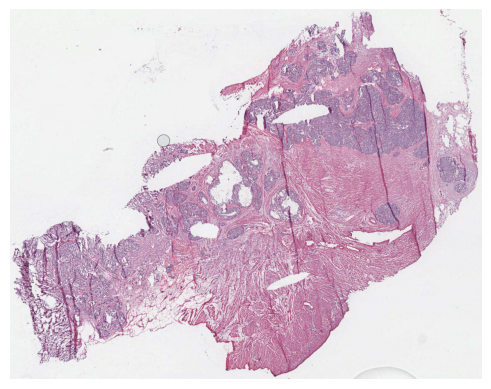

In [17]:
# Pega a menor dimensão disponível na imagem
level = len(wsi.level_dimensions) - 1

# Ler toda a imagem na menor dimensão
img = wsi.read_region((0, 0), level, wsi.level_dimensions[level]).convert('RGB')
plt.imshow(img)
plt.axis('off') # Esconde os eixos x e y
plt.show()

In [28]:
# Obtém o tamanho da imagem real
w, h = wsi.dimensions

# Define o tamanho do patch e o nível de leitura
patch_size = 224*4

if patch_size <= 0:
    raise ValueError("patch_size deve ser positivo")


# Torna as dimenções multiplas de patch_size
width = ((w + patch_size - 1)//patch_size)*patch_size
hight = ((h + patch_size - 1)//patch_size)*patch_size

tiles = DeepZoomGenerator(wsi, tile_size=patch_size, overlap=0)
dz_level = tiles.level_count - 1
dz_cols, dz_rows = tiles.level_tiles[dz_level]

In [29]:
width, hight

(103936, 81536)

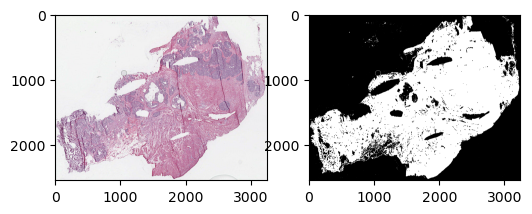

In [30]:
# Converte a imagem para tons de cinza
gray_img = cv.cvtColor(np.array(img), cv.COLOR_RGBA2GRAY)

# Aplica o limiar global
_, thresh = cv.threshold(gray_img, 0, 255, cv.THRESH_BINARY_INV+cv.THRESH_OTSU)

# Aplica uma operação morfológica para remover pequenos objetos e buracos na máscara
kernel = cv.getStructuringElement(cv.MORPH_ELLIPSE, (7, 7))
mask = cv.morphologyEx(thresh, cv.MORPH_CLOSE, kernel)

plt.figure(figsize=(6,10))

plt.subplot(1,2,1)
plt.imshow(img)

plt.subplot(1,2,2)
plt.imshow(mask, cmap='gray')

plt.show()

mask = cv.resize(mask, (width, hight))

del(gray_img, thresh, kernel, w, h, img)

### Quantização, modelo TFLITE

In [31]:
TF_LITE_QA_MODEL_FILE_NAME = '/home/ampliar/Desktop/aws-ia-heatmap-master/tubular-bin-4x-v2.tflite'

In [32]:
# Carregar o modelo TFLite
interpreter = tf.lite.Interpreter(model_path=TF_LITE_QA_MODEL_FILE_NAME)
interpreter.allocate_tensors()

# Obter detalhes do modelo
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Preparar os dados de entrada
input_shape = input_details[0]['shape']

## Gerando Heatmap

In [10]:
def processing_time(start_time, end_time):
    # Calcular métricas de desempenho
    total_time = end_time - start_time
    minutos, segundos = divmod(total_time, 60)
    milisegundos = int((segundos - int(segundos))*1000)

    print(f'Tempo de execução:\n00:0{int(minutos)}:{int(segundos)}.{milisegundos}')

#### Paralelismo

In [34]:
def _process_block(y, x):
#     y, x = args
    # Retorna uma lista de coordenadas que estão aptas para serem avaliadas
    return [(y + m, x + n) for m, n in product(indices, indices) if np.mean(mask[y + m:y + m+patch_size, x + n:x + n+patch_size]) > 16]

def _process_patch(abs_y, abs_x):
    
    tile_row = abs_y // patch_size
    tile_col = abs_x // patch_size

    if tile_row >= dz_rows or tile_col >= dz_cols:
        return None

    img_block = tiles.get_tile(dz_level, (tile_col, tile_row)).convert('RGB')

    # Converter o bloco para o formato numpy
    img_block = np.array(img_block, dtype=np.float32)[:, :, ::-1] # converter RGB para BGR
    
    # Redimensionar a imagem para 224x224
    img_block = cv.resize(img_block, (224, 224))

    # Adicionando uma dimensão extra para criar um batch de tamanho 1
    img_block = np.expand_dims(img_block, axis=0)

    # Definir os dados de entrada no tensor do modelo
    interpreter.set_tensor(input_details[0]['index'], img_block)

    # Executar a predição
    interpreter.invoke()

    # Obter os resultados da predição
    prediction_xy = interpreter.get_tensor(output_details[0]['index'])[0][1]

    if prediction_xy > TRASH_HOLD:

        # LIST
        return (int(tile_row), int(tile_col), prediction_xy)

### List Approach

In [36]:
# Definir parâmetros
c = 4
slide_dim = patch_size*c
indices = np.arange(0, slide_dim, patch_size)

# Determinar os índices dos blocos na imagem
y_indices = np.arange(0, hight, slide_dim)
x_indices = np.arange(0, width, slide_dim)

start_time = time.time()

# Matriz que irá receber as predições
jet_heatmap_matrix = np.zeros((int(hight/patch_size), int(width/patch_size)), dtype=np.float16)



results = [(y, x) for y, x in product(y_indices, x_indices) if np.mean(mask[y:y+slide_dim, x:x+slide_dim]) > 16]

# Processar a imagem em blocos em paralelo
with Pool() as pool:
    results = pool.starmap(_process_block, results)

results = [sublista for lista in results for sublista in lista]

print(f'Quantidde de imagens: {len(results)}')
with Pool() as pool:
    results = pool.starmap(_process_patch, results)

# Elimina as listas vazias e transforma a lista de listas em uma única lista de tuplas
results = [item for item in results if item is not None]

if len(results) > 0:
    results_array = np.array(results)
    y = np.int_(results_array[:, 0])
    x = np.int_(results_array[:, 1])
    valor = results_array[:, 2]
    jet_heatmap_matrix[y, x] = valor
else:
    print('Nenhum patch excedeu o threshold.')

# for y, x, valor in results:
#     jet_heatmap_matrix[y][x] = valor

end_time = time.time()

# Calcular métricas de desempenho
processing_time(start_time, end_time)

/home/ampliar/miniconda3/envs/tubular-tf-env/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/ampliar/miniconda3/envs/tubular-tf-env/lib/python3.9/site-packages/numpy/core/_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/home/ampliar/miniconda3/envs/tubular-tf-env/lib/python3.9/site-packages/numpy/core/fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/ampliar/miniconda3/envs/tubular-tf-env/lib/python3.9/site-packages/numpy/core/_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


Quantidde de imagens: 5405


KeyboardInterrupt: 

In [ ]:
# Definir parâmetros
c = 4
slide_dim = patch_size*c
indices = np.arange(0, slide_dim, patch_size)

# Determinar os índices dos blocos na imagem
y_indices = np.arange(0, hight, slide_dim)
x_indices = np.arange(0, width, slide_dim)

start_time = time.time()

# Matriz que irá receber as predições
jet_heatmap_matrix = np.zeros((int(hight/patch_size), int(width/patch_size)), dtype=np.float16)



results = [(y, x) for y, x in product(y_indices, x_indices) if np.mean(mask[y:y+slide_dim, x:x+slide_dim]) > 16]

# Processar a imagem em blocos em paralelo
with Pool() as pool:
    results = pool.starmap(_process_block, results)

results = [sublista for lista in results for sublista in lista]

print(f'Quantidde de imagens: {len(results)}')
with Pool() as pool:
    results = pool.starmap(_process_patch, results)

# Elimina as listas vazias e transforma a lista de listas em uma única lista de tuplas
results = [item for item in results if item is not None]

# Criar uma matriz numpy a partir de results, que é uma lista de tuplas
results_array = np.array(results)

# Extrair as coordenadas y, x e os valores de cada tupla
y = np.int_(results_array[:, 0])
x = np.int_(results_array[:, 1])
valor = results_array[:, 2]

# Usar indexação avançada para atribuir os valores às posições da matriz
jet_heatmap_matrix[y, x] = valor

# for y, x, valor in results:
#     jet_heatmap_matrix[y][x] = valor

end_time = time.time()

# Calcular métricas de desempenho
processing_time(start_time, end_time)

### Mostrando Mapa de Calor

In [ ]:
heatmap_matrix = np.uint8(255 * jet_heatmap_matrix)

jet_colors = cm.get_cmap("jet")(np.arange(256))[:, :3]
jet_heatmap = jet_colors[heatmap_matrix]

jet_heatmap = tf.keras.utils.array_to_img(jet_heatmap)

# Salvar a imagem como JPEG
jet_heatmap.save(f'heat_maps_images/hm_TCGA-RD-A8N6-01A-01-TS1_qat.jpg', quality=100)  # Ajuste o valor de qualidade (0-100) conforme necessário

In [ ]:
# Ler toda a imagem na menor dimensão
img = wsi.read_region((0, 0), 2, wsi.level_dimensions[2]).convert('RGB')

img_array = np.array(img, dtype=np.float32)#[:, :, ::-1]
jet_heatmap = Image.open('heat_maps_images/hm_TCGA-RD-A8N6-01A-01-TS1_qat.jpg')
jet_heatmap = jet_heatmap.resize((img_array.shape[1], img_array.shape[0]))

superimposed_img = np.array(jet_heatmap)*1 + img_array 
superimposed_img = tf.keras.utils.array_to_img(superimposed_img)
superimposed_img.save(f'heat_maps_images/superimposed_TCGA-RD-A8N6-01A-01-TS1_qat.jpg', quality=100)  # Ajuste o valor de qualidade (0-100) conforme necessário
# Plotando figuras
plt.figure(figsize=(10,12))
plt.imshow(superimposed_img)
plt.axis('off')

# Ajuste de layout
plt.tight_layout()

plt.show()